# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** [Enter Name]
**Student ID:** [Enter ID]

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [33]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

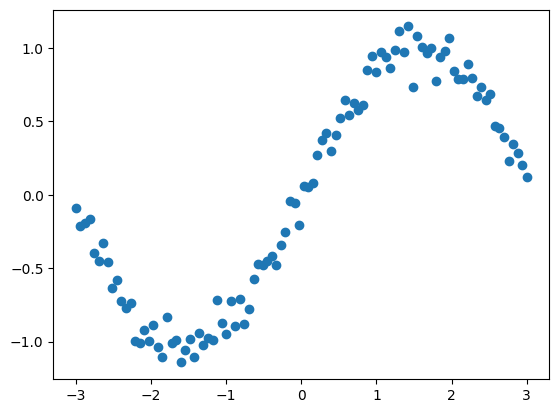

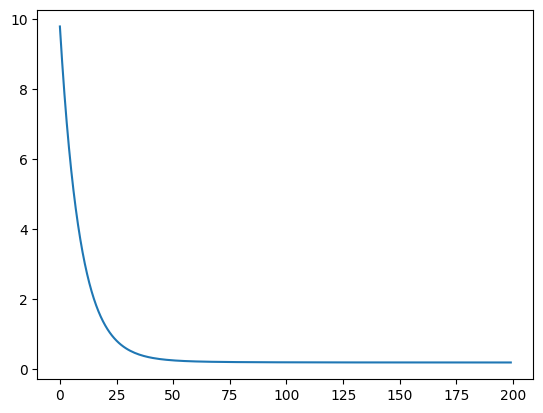

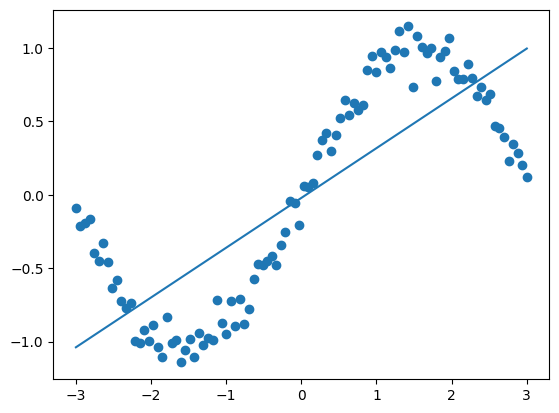

In [34]:
# TODO: Generate the toy data
x=np.linspace(-3,3,100)

y=np.sin(x) + np.random.normal(loc=0.0,scale=0.1,size=100)
#plotting it
plt.scatter(x,y)
plt.show()


# TODO: Initialise w and b to small random values.
w=np.random.randn()
b=np.random.randn()

# MSE
# dLoss/dw  (derive this on paper!)
# dLoss/db
# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   Record the loss at every step.
lossrecord=[]
for i in range(200):
    y_hat=w*x+b
    loss=np.mean((y_hat-y) ** 2)
    dw = np.mean(2 * (y_hat -y) * x)
    db = np.mean(2 * (y_hat -y))
    #lr = learning rate and how big each step is
    lr=0.009
    w-=lr *dw
    b-=lr *db
    lossrecord.append(loss)

# TODO: Plot (a) the loss curve over the 200 steps, and
plt.plot(lossrecord)
plt.show()

plt.scatter(x,y)
plt.plot(x,y_hat)
plt.show()
#             (b) the data with the fitted line on top.

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:*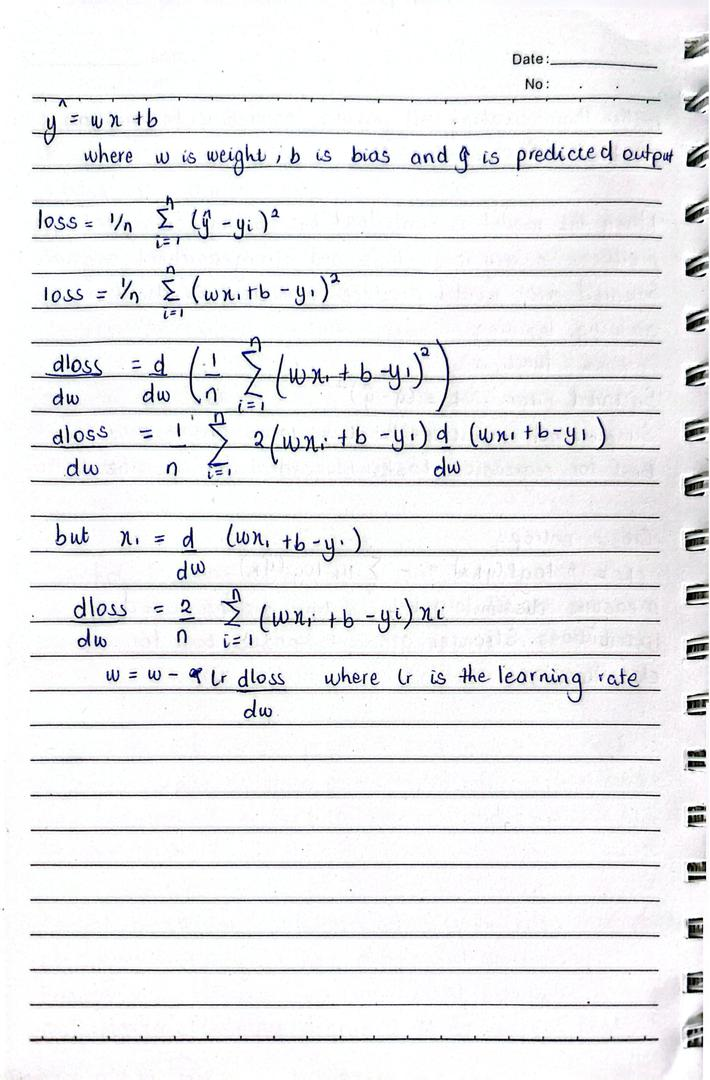
The loss stops improving but the fit is clearly bad. This indicates underfitting. The model's prediction (y_hat) uses a linear model for guessing and hence this always creates a straight line that cannot bend to follow the curve indicating that a simpler model is being used for a much complex structure.

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

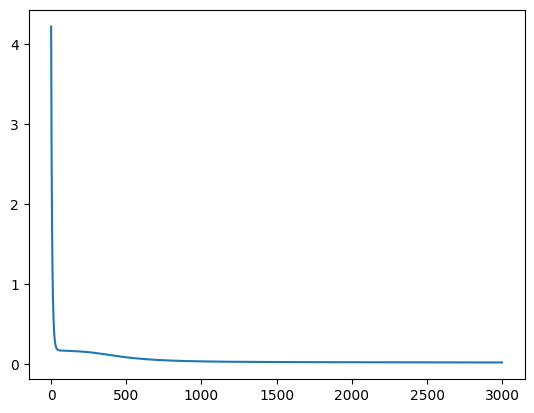

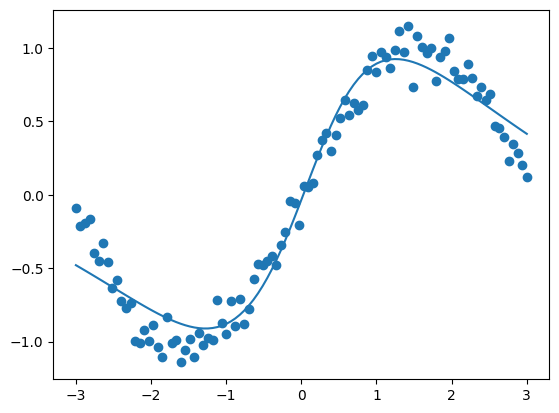

In [35]:


# TODO: Initialise parameters
w1=np.random.randn(1,8)*0.5
w2=np.random.randn(8,1)*0.5
b1=np.random.randn(8,)*0.5
b2=np.random.randn(1,)*0.5

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
x2 = x.reshape(100, 1)
y2 = y.reshape(100,1)
z1=(x2@ w1) +b1

#   h  = np.tanh(z1)        # activation
h=np.tanh(z1)
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
y_hat=(h@w2) + b2
#   loss  = np.mean((y_hat - y) ** 2)
loss=np.mean((y_hat-y2) **2)

# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
d_yhat=2 * (y_hat-y2)/len(y)

#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
dw2=h.T @d_yhat
db2=d_yhat.sum(axis=0)

#   dh  = d_yhat @ W2.T
dh=d_yhat@w2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
dz1 =dh * (1-np.tanh(z1) ** 2)
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)
dw1 = x.T @dz1
db1=dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
lr =0.009
loss_history=[]

for i in range(3000):

    z1=(x2@ w1) +b1
    h =np.tanh(z1)
    #h=z1

    y_hat=(h@w2) + b2

    loss=np.mean((y_hat-y2) **2)
    d_yhat=2 * (y_hat-y2)/len(y)
    dw2=h.T @d_yhat
    db2=d_yhat.sum(axis=0)
    dh=d_yhat@w2.T
    dz1 =dh * (1-np.tanh(z1) ** 2)
    dw1 = x2.T @dz1
    db1=dz1.sum(axis=0)

    w1-=lr *dw1
    b1-=lr *db1
    w2-=lr*dw2
    b2-=lr*db2

    loss_history.append(loss)




# TODO: Plot the loss curve AND the final fit over the data.
plt.plot(loss_history)
plt.show()

plt.scatter(x,y)
plt.plot(x,y_hat)
plt.show()


#Doing the hint to answer student reasoning
#

STUDENT REASONING
With tanh removed, the deep network fits no better than the single neuron of Part 1.1 and a stack of linear layers collapses into one linear layer. This is because an addition of multiple linear functions still gives a linear function and the tanh is the activation function that is introduced to produce non linearity and with that removed, the stack of layers are all just a straight line that cannot bend to fit adequately.

2.Each of The hidden layers of the 8 neurons contribute a bent shape to the curved using the tanh activation function. The w2 decides how much weight each of the 8 neurons is contributing to the curve and the b2 allows for shifting of the curve up and down.

3. Backpropagation is an algorithm that trains neural networks by computing gradients to reduce prediction error and works backward layer by layer since one layer's depends on another layer's gradient

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_508/1166710629.py:30: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat-y2)**2)
/tmp/ipykernel_508/1166710629.py:21: RuntimeWarning: overflow encountered in matmul
  dh=d_yhat@w2.T
/tmp/ipykernel_508/1166710629.py:22: RuntimeWarning: invalid value encountered in multiply
  dz1 =dh * (1-np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


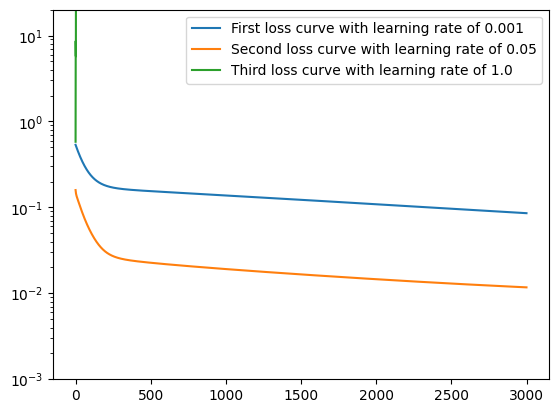

[np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]
1.7976931348623157e+308


In [36]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr,steps=3000):
    w1=np.random.randn(1,8)*0.5
    w2=np.random.randn(8,1)*0.5
    b1=np.random.randn(8,)*0.5
    b2=np.random.randn(1,)*0.5

    loss_history=[]
    for i in range(steps):
        z1=(x2@ w1) +b1
        h =np.tanh(z1)
        #h=z1

        y_hat=(h@w2) + b2


        d_yhat=2 * (y_hat-y2)/len(y)
        dw2=h.T @d_yhat
        db2=d_yhat.sum(axis=0)
        dh=d_yhat@w2.T
        dz1 =dh * (1-np.tanh(z1) ** 2)
        dw1 = x2.T @dz1
        db1=dz1.sum(axis=0)

        w1-=lr *dw1
        b1-=lr *db1
        w2-=lr*dw2
        b2-=lr*db2
        loss = np.mean((y_hat-y2)**2)
        loss_history.append(loss)
    return loss_history
losses = train_toy(lr=0.01)



# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
first_loss=train_toy(0.001,3000)
second_loss=train_toy(0.05,3000)
third_loss=train_toy(1.0,3000)
third_loss_clean = np.nan_to_num(third_loss, nan=1e10)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend

plt.plot(first_loss,label='First loss curve with learning rate of 0.001')

plt.plot(second_loss,label='Second loss curve with learning rate of 0.05')

plt.plot(third_loss_clean, label='Third loss curve with learning rate of 1.0')

plt.yscale('log')
plt.ylim(1e-3, 20)

plt.legend()

plt.show()

print(third_loss[-5:])
print(max(third_loss_clean))

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** [STUDENT REASONING
The blue curve that has a learning rate of 0.001 drops quite slow, the orange curve that has a learning rate of 0.05 drops faster and the green curve with a learning rate of 1.0 explodes.The large learning rate makes the loss explodes instead of just learning faster because the w and b shoots up making the prediction more wrong than before instead of shifting towards the right answer.]

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [37]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
obesity = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv")

# TODO: Encode categoricals exactly as you did in Lab 2
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    obesity[col] = obesity[col].map({'yes': 1, 'no': 0})

order_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
obesity['CAEC'] = obesity['CAEC'].map(order_map)
obesity['CALC'] = obesity['CALC'].map(order_map)


obesity['NObeyesdad_encoded'] = LabelEncoder().fit_transform(obesity['NObeyesdad'])
obesity = pd.get_dummies(obesity, columns=['Gender', 'MTRANS'], drop_first=True)

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X = obesity.drop(columns=['NObeyesdad', 'NObeyesdad_encoded'])
y = obesity['NObeyesdad_encoded']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp)



# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long

x_train_tensor= torch.tensor(X_train_scaled,dtype=torch.float32)
x_val_tensor=torch.tensor(X_val_scaled,dtype=torch.float32)
x_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)

y_train_tensor=torch.tensor(y_train.values,dtype=torch.long)
y_val_tensor=torch.tensor(y_val.values,dtype=torch.long)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.long)

#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset=TensorDataset(x_val_tensor,y_val_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=32,shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)



**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:** [STUDENT REASONING
1.The cross entropy loss formula calculates the probability that a model assigned to the correct answer. If there is high confidence in the correct answer there is low loss and if there is low confidence in the correct answer there is high loss. PyTorch's Cross Entropy Loss just needs to find out which class is correct and an integer is enough to find that, using the one hot encoding vector become unnecessary since it does not contribute anything to finding the confidence value.

2.Neural networks care about feature scaling soo much because without scaling larger values produce very large gradients and causes explosion unlike random forests that split data into thresholds rather than gradient magnitudes and hence they are not affected by raw scale values.
Using the gradient formula ; dw=mean(2"(y_hat-y)*x), without scaling x, we end up with very large gradients that causes the explosions since x is multiplied directly.

3.shuffle=True randomly mixes up rows in the dataset and hence the model doesn't learn a fixed sequence but rather it learns the actual patterns in the datasets instead of overfitting.
]

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [38]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
class FeedForwardNet(nn.Module):
    def __init__(self,input_dim,hidden_sizes=(64,32),n_classes=7,dropout=0.0):
        super().__init__()
        self.first_layer=nn.Linear(input_dim,hidden_sizes[0])
        self.second_layer=nn.Linear(hidden_sizes[0],hidden_sizes[1])
        self.third_layer=nn.Linear(hidden_sizes[1],n_classes)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2=nn.Dropout(dropout)


    def forward(self,x):
        h1 = torch.relu(self.first_layer(x))
        h1 = self.dropout1(h1)
        h2=torch.relu(self.second_layer(h1))
        h2=self.dropout2(h2)
        output = self.third_layer(h2)

        return output

# TODO: Instantiate, move to DEVICE, print the model.
print(X_train.shape)
model = FeedForwardNet(input_dim=19)
model=model.to(DEVICE)
print(model)

# TODO: Count trainable parameters:
sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
#input_dim = 19
#19*64+64=1280


(1266, 19)
FeedForwardNet(
  (first_layer): Linear(in_features=19, out_features=64, bias=True)
  (second_layer): Linear(in_features=64, out_features=32, bias=True)
  (third_layer): Linear(in_features=32, out_features=7, bias=True)
  (dropout1): Dropout(p=0.0, inplace=False)
  (dropout2): Dropout(p=0.0, inplace=False)
)


3591

**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:** [STUDENT REASONING
1. first_layer
input_dim=19
19*64+64 = 1280

second_layer
input_dim=64
64*32+32=2080

third_layer
input_dim=32
32*7+7=231

Total = 1280+2080+231 =3591

The calculation matches the PyTorch.  
2. During back propagation the gradients get multiplied together when there is a flow through each layer. The gradient of tanh is very small quite closs to 0 and this causes shrinkage. The gradient of ReLu is always 1 and hence no shrinkage can occur. With this, it allows effective training of deep learning networks.
3. Without the ReLU the network would justt compute linear models since the ReLU is what introduces the non linearity. ]

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch 1: train_loss=1.8085, train_acc=0.3610, val_loss=1.8158, val_acc=0.3744
Epoch 2: train_loss=1.5506, train_acc=0.5553, val_loss=1.5628, val_acc=0.5758
Epoch 3: train_loss=1.1708, train_acc=0.6256, val_loss=1.1827, val_acc=0.6374
Epoch 4: train_loss=0.9146, train_acc=0.6556, val_loss=0.9327, val_acc=0.6588
Epoch 5: train_loss=0.7567, train_acc=0.7686, val_loss=0.7941, val_acc=0.7251
Epoch 6: train_loss=0.6462, train_acc=0.7844, val_loss=0.6970, val_acc=0.7512
Epoch 7: train_loss=0.5597, train_acc=0.8246, val_loss=0.6253, val_acc=0.7867
Epoch 8: train_loss=0.4890, train_acc=0.8570, val_loss=0.5645, val_acc=0.8270
Epoch 9: train_loss=0.4253, train_acc=0.8744, val_loss=0.5107, val_acc=0.8318
Epoch 10: train_loss=0.3761, train_acc=0.8823, val_loss=0.4709, val_acc=0.8412
Epoch 11: train_loss=0.3341, train_acc=0.8989, val_loss=0.4385, val_acc=0.8341
Epoch 12: train_loss=0.2993, train_acc=0.9155, val_loss=0.4101, val_acc=0.8460
Epoch 13: train_loss=0.2706, train_acc=0.9202, val_loss=0.387

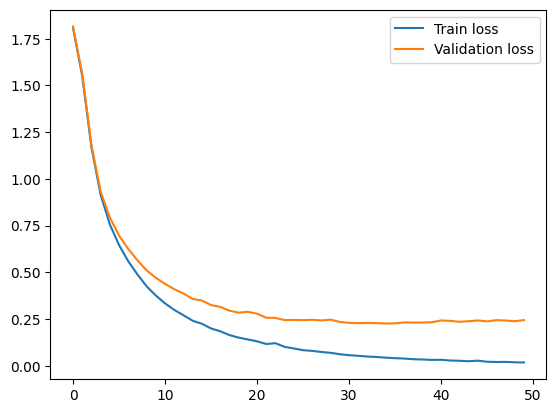

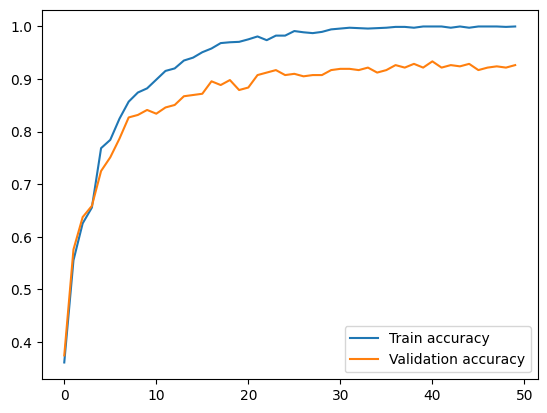

In [39]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
 #I used Adam because it is more advanced and combines the adavantages of Momentum and RMSprop techniques to adjust rates during learning.
 #It adjist step size based on gradient history instead of using a specific learning history.

# TODO: Train for at least 50 epochs. Each epoch:
# model.train()
# for xb, yb in train_loader:
#    optimizer.zero_grad()
#    logits = model(xb.to(DEVICE))
#    loss = criterion(logits, yb.to(DEVICE))
#    loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#    optimizer.step()         # <- the update rule you wrote in Part 1.1
#    model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets

train_losses=[]
train_accuracies=[]
val_losses=[]
val_accuracies=[]
best_val_accuracy = 0

for epoch in range(50):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb.to(DEVICE))
        loss = criterion(logits, yb.to(DEVICE))
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
      train_loss = 0 #to calculate the running total of each loss
      train_correct = 0 #to calculate the correct total of each loss
      train_total = 0  #to calaculate the total number checked so far
      for xb,yb in train_loader:
        logits = model(xb.to(DEVICE))
        loss=criterion(logits,yb.to(DEVICE))
        train_loss += loss.item() * xb.size(0)
        predictions = torch.argmax(logits, dim=1)
        train_correct += (predictions == yb.to(DEVICE)).sum().item()
        train_total += xb.size(0)
      train_accuracy = train_correct / train_total
      val_loss=0
      val_correct=0
      val_total=0
      for xb,yb in val_loader:
        logits = model(xb.to(DEVICE))
        loss=criterion(logits,yb.to(DEVICE))
        val_loss += loss.item() * xb.size(0)
        predictions = torch.argmax(logits, dim=1)
        val_correct += (predictions == yb.to(DEVICE)).sum().item()
        val_total += xb.size(0)
      val_accuracy=val_correct/val_total
      train_losses.append(train_loss/train_total)
      train_accuracies.append(train_accuracy)
      val_losses.append(val_loss/val_total)
      val_accuracies.append(val_accuracy)

      if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), "ffn_best.pt")


      print(f"Epoch {epoch+1}: train_loss={train_loss/train_total:.4f}, train_acc={train_accuracy:.4f}, val_loss={val_loss/val_total:.4f}, val_acc={val_accuracy:.4f}")









#   3. Append everything to history lists; print a one-line summary per epoch.

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")
torch.save(model.state_dict(),"ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
plt.plot(train_losses,label='Train loss')
plt.plot(val_losses,label='Validation loss')
plt.legend()
plt.show()

plt.plot(train_accuracies,label='Train accuracy')
plt.plot(val_accuracies,label='Validation accuracy')

plt.legend()

plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** logits = model(xb.to(DEVICE)) in the PyTorch loop is equivalent to calculating the values of z1,h,y_hat in the Numpy code.   
loss.backward() in the Pyorch loop is equivalent to calculating the gradients d_yhat,dw2,db2 ,dh ,dz1,dw1 and db2 in the Numpy code.       The optimizer.step() is the update rule in the PyTorch loop, and it is equivalent to w1 -= lr*dw1 and b1 -= lr*db1 in the Numpy code in section 1.

2. Looking at my curves I think the model is overfitting. To back up this claim , I would use epochs 15,30 and 50.
At epoch 15 we have a training accuracy of 100%(1.00) same for epochh 30 and 50. Meaning the training performance was very perfect.
At epoch 15, we have a validation accuracy of 0.9265 , epoch 30 has a validation accuracy of 0.9336, and epoch 50 has a validation accuracy of 0.9408. The validation accuracy between these three epochs were between 92.5% to 94% showing that there is a 6% gap between training accuracy and validation accurcay.
The training losses from the epochs 15,30 and 50 were 0.0057,0.0021 and 0.0009 respectively indicating that percentage loss was very small , almost zero. But the validation losses for epochs 15,30 and 50 were 0.2848,0.3106 and 0.3439 respectively showing that validation loss continued to increase quite significantly.
These values confirms the fact that The model was overfitting.

3.We call optimizer.zero_grad() after every batch to ensure that previous gradients are cleared and that each new batch gradient is calculated based on the current batch and not added to the previous batch's gradient. The problem that silently occurs if we do not use this is that the weights and gradients are corrupted which causes inaccuracy but does not throw an error.

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

0.8601895734597157
0.9407582938388626
0.9289099526066351


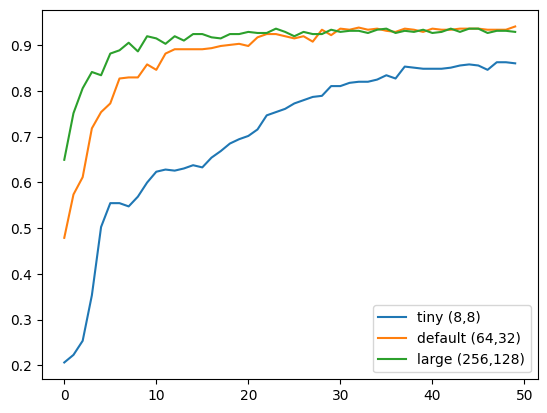

0.7588145597286134
0.24303924087523285
2.153898302412711


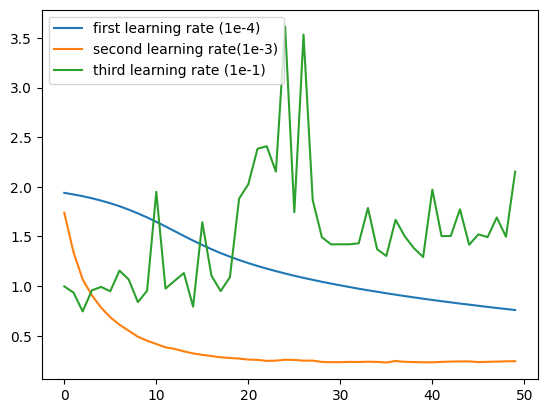

1.0
0.9265402843601895
0.9984202211690363
0.9265402843601895


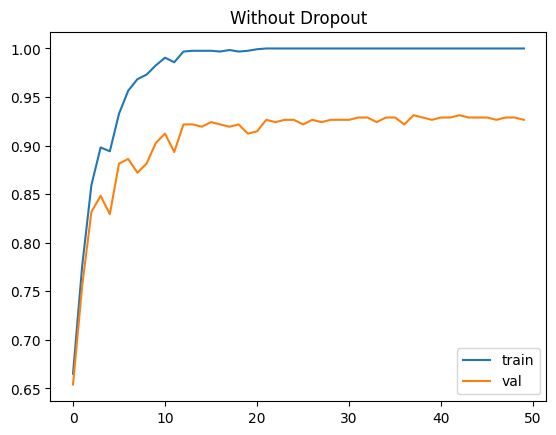

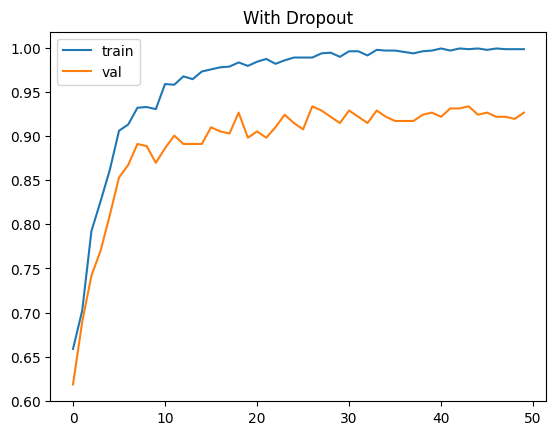

In [40]:
# Wrap your Part 2.3 loop in a function first:
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
  model = FeedForwardNet(input_dim=19, hidden_sizes=hidden_sizes, dropout=dropout).to(DEVICE)
  torch.manual_seed(RANDOM_STATE)
  model=model.to(DEVICE)
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  criterion = nn.CrossEntropyLoss()
  train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
  val_loader=DataLoader(val_dataset,batch_size=batch_size,shuffle=False)

  train_accuracies=[]
  val_accuracies=[]
  train_losses=[]
  val_losses=[]
  best_val_accuracy=0


  for epoch in range(epochs):
    model.train()
    for xb,yb in train_loader:
      optimizer.zero_grad()
      logits=model(xb.to(DEVICE))
      loss=criterion(logits,yb.to(DEVICE))
      loss.backward()
      optimizer.step()
    model.eval()
    with torch.no_grad():
      train_loss=0
      train_correct=0
      train_total=0
      for xb,yb in train_loader:
        logits=model(xb.to(DEVICE))
        loss=criterion(logits,yb.to(DEVICE))
        train_loss += loss.item() * xb.size(0)
        predictions = torch.argmax(logits, dim=1)
        train_correct += (predictions == yb.to(DEVICE)).sum().item()
        train_total += xb.size(0)
      train_accuracy = train_correct / train_total
      val_loss=0
      val_correct=0
      val_total=0
      for xb,yb in val_loader:
        logits = model(xb.to(DEVICE))
        loss=criterion(logits,yb.to(DEVICE))
        val_loss += loss.item() * xb.size(0)
        predictions = torch.argmax(logits, dim=1)
        val_correct += (predictions == yb.to(DEVICE)).sum().item()
        val_total += xb.size(0)
      val_accuracy=val_correct/val_total
      train_losses.append(train_loss/train_total)
      train_accuracies.append(train_accuracy)
      val_losses.append(val_loss/val_total)
      val_accuracies.append(val_accuracy)

      if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), "ffn_best.pt")


  history = {
      'train_accuracies': train_accuracies,
      'val_accuracies': val_accuracies,
      'train_losses': train_losses,
      'val_losses': val_losses
            }
  return history




# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.
tiny = run_experiment(hidden_sizes=(8,8))
default = run_experiment(hidden_sizes=(64,32))
large = run_experiment(hidden_sizes=(256, 128))

print(tiny['val_accuracies'][-1])
print(default['val_accuracies'][-1])
print(large['val_accuracies'][-1])
#I used two values in the large capacity because my feedforward net in part 2.2 was hard coded to take just two hidden values

plt.plot(tiny['val_accuracies'], label='tiny (8,8)')
plt.plot(default['val_accuracies'], label='default (64,32)')
plt.plot(large['val_accuracies'], label='large (256,128)')
plt.legend()
plt.show()

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.
first_lr = run_experiment(lr=1e-4)
second_lr = run_experiment(lr=1e-3)
third_lr = run_experiment(lr=1e-1)

print(first_lr['val_losses'][-1])
print(second_lr['val_losses'][-1])
print(third_lr['val_losses'][-1])

plt.plot(first_lr['val_losses'], label='first learning rate (1e-4)')
plt.plot(second_lr['val_losses'], label='second learning rate(1e-3)')
plt.plot(third_lr['val_losses'], label='third learning rate (1e-1)')
plt.legend()
plt.show()

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#without nn.Dropout
torch.manual_seed(RANDOM_STATE)
no_dropout = run_experiment(hidden_sizes=(256,128), dropout=0.0)
print(no_dropout['train_accuracies'][-1])
print(no_dropout['val_accuracies'][-1])


#with nn.dropout
torch.manual_seed(RANDOM_STATE)
with_dropout = run_experiment(hidden_sizes=(256,128), dropout=0.3)
print(with_dropout['train_accuracies'][-1])
print(with_dropout['val_accuracies'][-1])

#   Plot train vs validation accuracy for both runs.
plt.plot(no_dropout['train_accuracies'], label='train')
plt.plot(no_dropout['val_accuracies'], label='val')
plt.legend()
plt.title('Without Dropout')
plt.show()

plt.plot(with_dropout['train_accuracies'], label='train')
plt.plot(with_dropout['val_accuracies'], label='val')
plt.legend()
plt.title('With Dropout')
plt.show()

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** [The largest network did not win on validation data. This is because going from default to large network did not show any extra validation accuracy. The extra capacity of the largest network is used to memorize noise and quirks in the training data and this causes overfitting in the long run. I see overfitting in experiment C where the training accuracy gave 1.0 and the validation accuracy gave about 0.9265 which gives a gap of about 8% inidicating that the model overfitted.

2. The three regimes match what I saw in part 1.3.but the "too hot" case is not identifical since in part 1.3 it fully diverged to nan with the raw gradient and experiment B only oscillated because of the usage of the Adam optimizer.

3. Dropout randomily zeroes 30% of the neurons of each batch during training and as a result training accuracy does not meaningfully drop but comes down to about 0.9984 whiles the validation accuracy stays significantly the same around 092654. This is does not affect the training vs validation gap since it still stays at a gap of about 8%. ]

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

0.933649289099526
Test Accuracy: 0.9290780141843972
Test Macro-F1: 0.9275369187780891


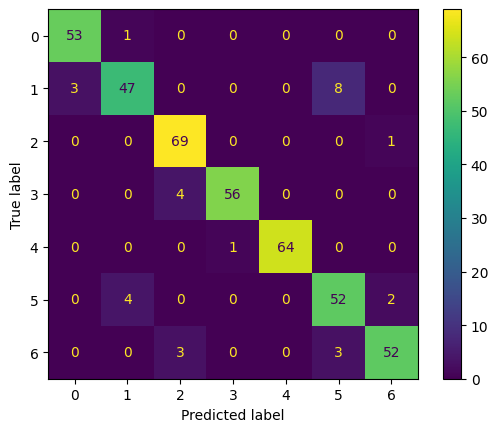

0.6058330535888672
5.237398862838745
                    Model  Test Accuracy  Test Macro-F1  Training Time (s)  \
0   Random Forest (Lab 2)         0.9910         0.9900           0.605833   
1  Feedforward NN (Lab 3)         0.9291         0.9275           5.237399   

   Parameters/Trees  
0               100  
1              3591  


In [41]:
# TODO: Load your best configuration's weights; model.eval().

torch.manual_seed(RANDOM_STATE)
final_model_history = run_experiment(hidden_sizes=(64,32), lr=1e-3, dropout=0.0)
print(final_model_history['val_accuracies'][-1])

model = FeedForwardNet(input_dim=19, hidden_sizes=(64,32), dropout=0.0).to(DEVICE)
model.load_state_dict(torch.load("ffn_best.pt"))
model.eval()

# TODO: Report test ACCURACY and MACRO-F1
from sklearn.metrics import accuracy_score, f1_score, classification_report

all_predictions = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb.to(DEVICE))
        preds = torch.argmax(logits, dim=1)
        all_predictions.extend(preds.cpu().numpy())
        all_labels.extend(yb.numpy())

test_accuracy = accuracy_score(all_labels, all_predictions)
test_f1_macro = f1_score(all_labels, all_predictions, average='macro')

print("Test Accuracy:", test_accuracy)
print("Test Macro-F1:", test_f1_macro)

# TODO: Confusion matrix for the test set with the 7 class names
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(all_labels, all_predictions)
plt.show()


# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
import time
from sklearn.ensemble import RandomForestClassifier

start = time.time()
rf_model = RandomForestClassifier(random_state=RANDOM_STATE)
rf_model.fit(X_train_scaled, y_train)
rf_training_time = time.time() - start
print(rf_training_time)
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]
import time

torch.manual_seed(RANDOM_STATE)
start = time.time()
final_model_history = run_experiment(hidden_sizes=(64,32), lr=1e-3, dropout=0.0)
nn_training_time = time.time() - start
print(nn_training_time)


comparison = pd.DataFrame({
    'Model': ['Random Forest (Lab 2)', 'Feedforward NN (Lab 3)'],
    'Test Accuracy': [0.991, 0.9291],
    'Test Macro-F1': [0.990, 0.9275],
    'Training Time (s)': [rf_training_time, nn_training_time],
    'Parameters/Trees': [100, 3591]
})
print(comparison)




In [32]:
print(X_train_scaled.shape)

(1266, 19)


**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [The network still confuses CLASS 1 which is normal_weight and CLASS 5 which is Overweight level causing 8 misclassifications and a huge error. The network also confuses class 5 (Overweight_level I) and class 6 (Overweight_levelII). I also confuses class 2(Obesity Type I ) and class 3 (obesisty type II). This is because all these classes are next to each on the BMI scale. These are also the same ones that Lab 2 classifier confused.

2. The classical model wins since it had a 0.9910 test accuracy which is almost a 100% test accuracy with very little effort. By this , the extra effort of deep learning in THIS dataset was not worth it.The extra effort in this dataset would be worth it, if there were more rows , preferably more than the 2100 rows we had. This is because deep learning requires huge datasets to perform exceptionally well. These large datasets can include images, huge texts and audio where the neural networks would have a very huge advantage compared to the classical model. ]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [1.  loss.backwad() calculates the gradients backward and it starts from the output loss value.
 loss.backward() adds newly computed gradients to the already existing ones  
 optimizer.step() modifies weights by overwriting the internal parameter values.

 2.A hyperparameter is a parameter whose value is set before the maching learning model begins learning.In this lab we saw hyperparameters like hidden layer sizes and learning rates. If I could tune only one hyperparameter, I would tune the learning rate hyperparameter because it has the most effect on whether training a model works at all. When the learning rate was small, the model barelt learned anything and when it was too large (1) it exploded.

 3.I saw the biggest train vs validation gap in experiment C's large netwrok. In that experiment, the training accuracy was 1.0 and the validation accuracy was still 0.9265, which created a gap of about 8%. Since the training accuracy was a perfect 100 and there still exists a huge training vs validation gap, the model overfitted. The dropout intervention was tested and there was no significant reduction in the gap, with that I do not think any of my interventions reduced the gap at all.

 4. In the next lab when we move to images the plain MLP will struglle because the plain MLP treats every input as independent and does not understand the spatial relationships between them whereby images require spatial relationships to depict a meaning or visual.Also , plain MLPs cannot reuse previously learned patterns to help detection of images. A better architecture should be able to detect patterns like edges, shapes and textures no matter where it appeared in an image by using filters across the whole image. In deep learning the best architecture would be the convolutional neural network.]

---
### Submission checklist

- [ ✅] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ✅] Every **Student Reasoning** box is filled in with full sentences.
- [ ✅] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ✅]: Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ✅] Repository link submitted to the course portal.
- [ ✅] AI Declaration form in Repository.